In [1]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

In [2]:
# Use Arial for font
mpl.rcParams['font.family'] = 'Arial'
mpl.rcParams['mathtext.fontset'] = 'custom'
mpl.rcParams['mathtext.rm'] = 'Arial'
mpl.rcParams['mathtext.it'] = 'Arial:italic'
mpl.rcParams['mathtext.bf'] = 'Arial:bold'

In [3]:
# Define parameters
pars = {
    'K_g': 3200 * 10**6,
    's': 10**(-7)
}
pars['d_max'] = 1
pars['sigma'] = 0.28 * pars['K_g']

pars_fv1 = {
    'p': 0.1,
    'sigma_p': 100 * pars['K_g']
}
pars_fv2 = {
    'p': 0.9,
    'sigma_p': 0.29 * pars['K_g']
}

R = np.linspace(0, 1.5 * pars['K_g'], 500)

In [4]:
# Define functions
def f(R, pars):
    return pars['d_max'] / (1 + np.exp(pars['s'] * (R - pars['sigma'])))

def f_v(R, p, sigma_p, s):
    return p / (1 + np.exp(s * (R - sigma_p)))

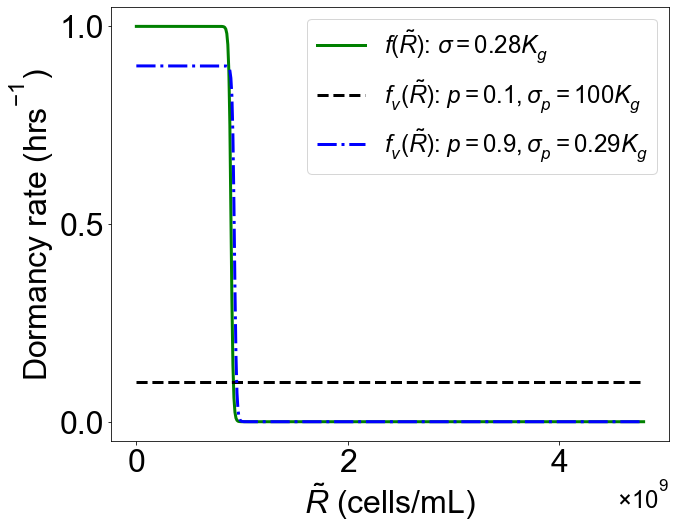

In [7]:
# Plot the 3 f functions (Dormancy rate because of starvation VS 2 cases of domrnacy rate because of direct interaction with viruses)
f_vals = f(R, pars)
f_v1_vals = f_v(R, pars_fv1['p'], pars_fv1['sigma_p'], pars['s'])
f_v2_vals = f_v(R, pars_fv2['p'], pars_fv2['sigma_p'], pars['s'])

fig, ax = plt.subplots(figsize=[10,8])

formatter = ScalarFormatter(useMathText=True)
formatter.set_powerlimits((0, 0))
ax.xaxis.set_major_formatter(formatter)

ax.plot(R, f_vals, color='green', lw=3, linestyle='-', label='$f(\\tilde{R})$: $\\sigma=0.28K_g$')
ax.plot(R, f_v1_vals, color='black', lw=3, linestyle='--', label='$f_v(\\tilde{R})$: $p=0.1, \\sigma_p=100K_g$')
ax.plot(R, f_v2_vals, color='blue', lw=3, linestyle='-.', label='$f_v(\\tilde{R})$: $p=0.9, \\sigma_p=0.29K_g$')

ax.set_xlabel('$\\tilde{R}$ (cells/mL)', fontsize=32)
ax.set_ylabel('Dormancy rate (hrs$^{-1}$)', fontsize=32)
ax.tick_params(axis='both', labelsize=32)
ax.ticklabel_format(style='sci', axis='x', scilimits=(9,9))
ax.xaxis.offsetText.set_fontsize(24)
ax.xaxis.offsetText.set_position((1, 1))
ax.yaxis.offsetText.set_position((-5, -5))
ax.set_yticks([0, 0.5, 1.0])

ax.legend(loc='upper right', fontsize=24)

plt.show()
#fig.savefig('Supplementary figure - modeling - compare dormancy rate functions.pdf', bbox_inches='tight', pad_inches=0);